In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]

Original image size: 2330x2284
Rescaled image size: 1000x980


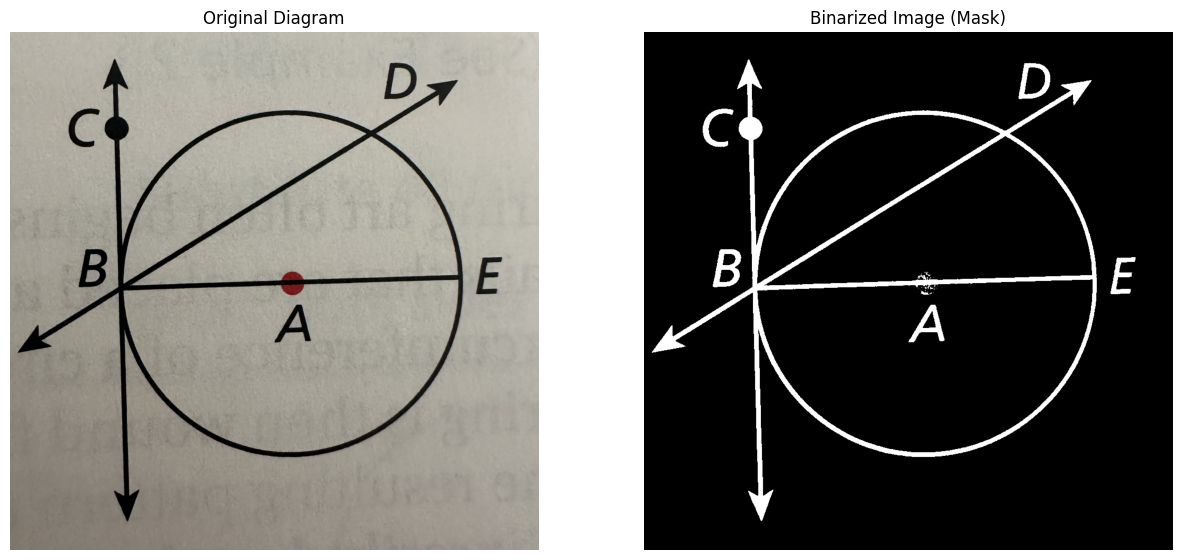

In [2]:
# load image and preprocess
img_bgr = cv2.imread('diagram_sample_image/circle9.jpg')

# scale image so that longest side is 1000 pixels
width, height = img_bgr.shape[1], img_bgr.shape[0]
max_dim = max(height, width)
scale_factor = 1000 / max_dim
img_bgr = cv2.resize(img_bgr, (int(width * scale_factor), int(height * scale_factor)), interpolation=cv2.INTER_AREA)
print(f"Original image size: {width}x{height}")
print(f"Rescaled image size: {img_bgr.shape[1]}x{img_bgr.shape[0]}")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_blur = cv2.bilateralFilter(img_gray, 9, 75, 75)

_, img_binary = cv2.threshold(img_gray, 50, 100, cv2.THRESH_BINARY_INV) # original 127, 255
img_edge = cv2.Canny(img_gray, 50, 150, apertureSize=3)

# 2. Define a structural element (kernel size must be larger than line thickness)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (12, 12))

# 3. Apply Closing to fill the gap between the edges
solid_line = cv2.morphologyEx(img_edge, cv2.MORPH_CLOSE, kernel)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Diagram")
ax[0].axis('off')

ax[1].imshow(img_binary, cmap='gray')
ax[1].set_title("Binarized Image (Mask)")
ax[1].axis('off')
plt.show()

## Detect dots/circles/lines

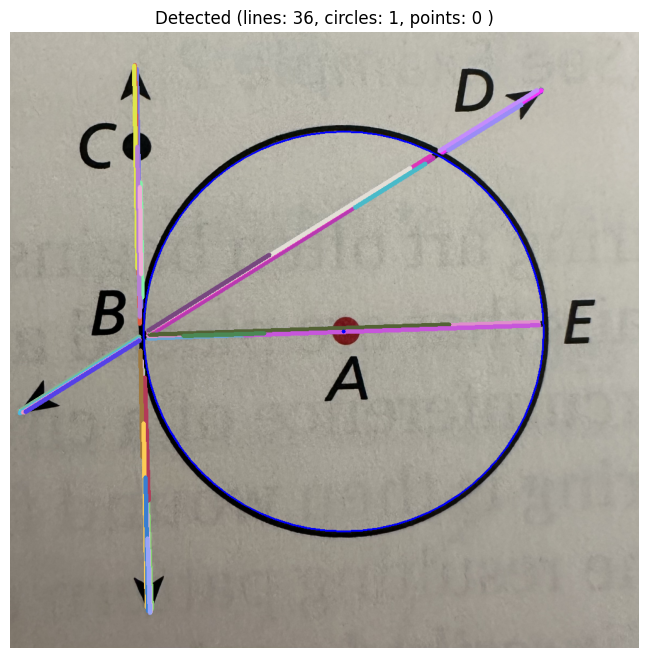

In [3]:
from draw_figures import draw_segments_on_image
from combine_geometry import mask_circles, get_all_points_on_circles

dots = cv2.HoughCircles(
        img_blur, 
        cv2.HOUGH_GRADIENT, 
        dp=1, 
        minDist=100, 
        param1=100, 
        param2=15, 
        minRadius=15, 
        maxRadius=30,
    )

circles = cv2.HoughCircles(
    img_blur, 
    cv2.HOUGH_GRADIENT, 
    dp=1, 
    minDist=200, 
    param1=100, 
    param2=50, 
    minRadius=100, 
    maxRadius=500
)
points_on_circles = np.empty((0, 2))

if circles is not None:
    if dots is not None:
        points_on_circles = get_all_points_on_circles(dots, circles, 5)

    cleaned_binary = mask_circles(img_binary, circles)
    lines = cv2.HoughLinesP(cleaned_binary, rho=1, theta=np.pi/180, threshold=250, minLineLength=100, maxLineGap=0)

else:
    lines = cv2.HoughLinesP(img_binary, rho=1, theta=np.pi/180, threshold=100, minLineLength=100, maxLineGap=0)

line_img = img_bgr.copy()


draw_segments_on_image(line_img, lines = lines, circles=circles, points = points_on_circles)


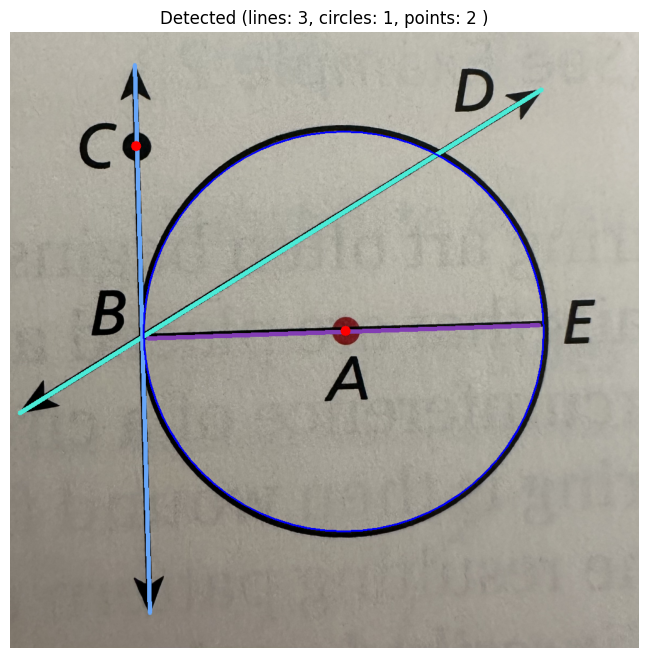

In [4]:
from combine_geometry import combine_lines, get_all_points_on_lines

combined_lines = combine_lines(lines)
points_on_lines = np.empty((0, 2))
# points on line
if dots is not None:
    points_on_lines = get_all_points_on_lines(dots, combined_lines, 5)


draw_segments_on_image(line_img, combined_lines, circles = circles, points = points_on_lines)

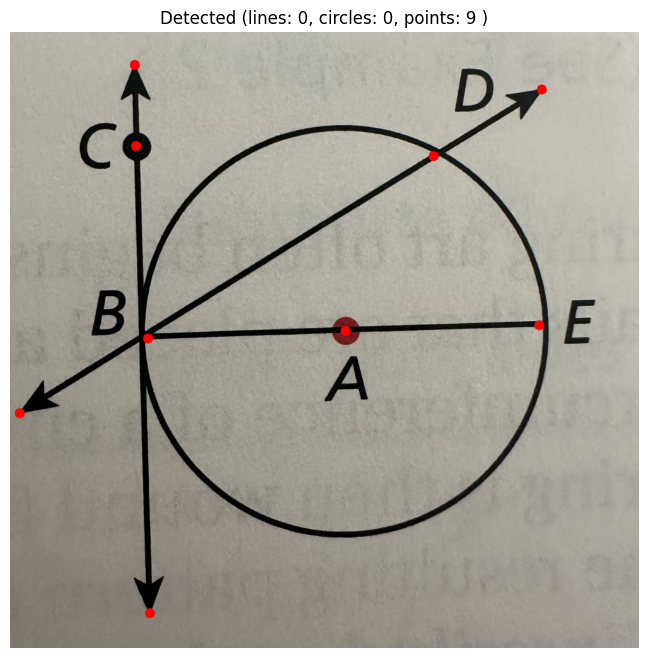

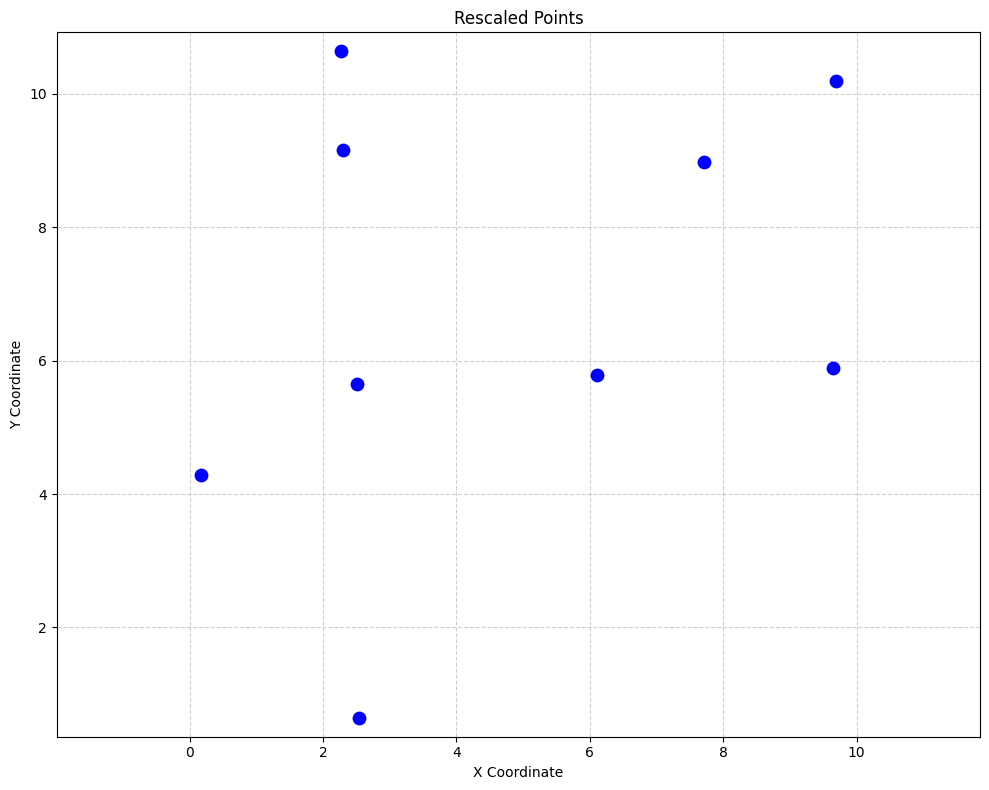

[(0.17201834862385323, 6.94954128440367), (2.2706422018348627, 0.5963302752293578), (2.511467889908257, 5.5848623853211015), (9.690366972477065, 1.0435779816513762), (2.5458715596330275, 10.596330275229358), (9.644495412844037, 5.344036697247707), (6.112385321100918, 5.447247706422019), (2.293577981651376, 2.0756880733944953), (7.717889908256881, 2.2591743119266057)]


In [6]:
from draw_figures import draw_segments_on_image, plot_points
from combine_geometry import (get_all_intersection_points, get_distinct_points, rescale_points, align_points, force_align_points, get_all_tangency_points,get_line_circle_intersection_points)

# points from line ends
points = combined_lines.reshape(-1, 4)[:, :2].tolist()
points.extend(combined_lines.reshape(-1, 4)[:, 2:4].tolist())
# points from intersections
intersection_points = get_all_intersection_points(combined_lines)  
points.extend(intersection_points)
# points on line
points.extend(points_on_lines)

# points from circle & tangency
if circles is not None:
    points.extend(points_on_circles)
    circle_center_points = np.array(circles, dtype=np.float32).reshape(-1, 3)[:,:2]
    points.extend(circle_center_points)
    tangency_points = get_all_tangency_points(combined_lines, circles)
    points.extend(tangency_points)
    circle_intersection_points = get_line_circle_intersection_points(combined_lines, circles, threshold = -5)
    points.extend(circle_intersection_points)

distinct_points = get_distinct_points(points, threshold=60)
draw_segments_on_image(img_bgr, points=distinct_points)


rescaled_points, scale = rescale_points(distinct_points)

flipped_points = np.array(rescaled_points)
flipped_points[:, 1] = img_bgr.shape[0]*scale - flipped_points[:, 1]

plot_points(flipped_points, "Rescaled Points")
# aligned_points = force_align_points(rescaled_points)
# plot_points(aligned_points, "Aligned Points")
# print(aligned_points)
print(flipped_points)